#  The resource-consumer NP model with odeint

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [2]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [3]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

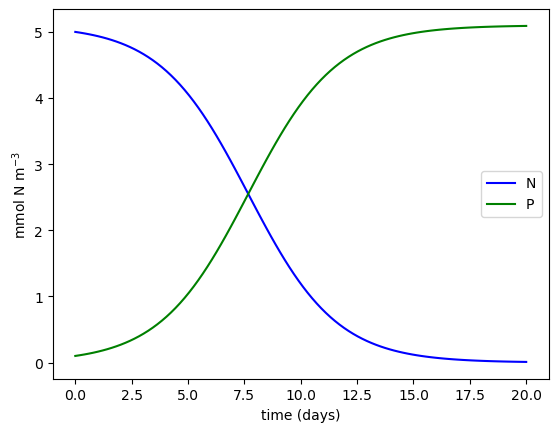

In [4]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

#### AI declaration
Gemini was used to anwer this exercise, i copied and paste the exercise to AI 
prompt used: "help me write a new model from the equation provided (eq4) to stimulate the (NPD) system and plot a graph using the odient to see the output.

# Exercise 7
1. What are the inputs and outputs in the function model? What kind of objects are they?
   
   **The input are the intial condition 'k' growth rate and the output are N0 intial which is the nutrients object and P0 is the phythoplankton object**

2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

In [12]:
# NUTRIENT-PHYTOPLANKTON-DETRITUS (NPD) MODEL
def model(y, t, rg, m, r):
    """4
    NPD model

    N = Nutrient concentration
    P = Phytoplankton concentration
    D = Detritus concentration

    rg = phytoplankton growth rate
    m  = mortality rate
    r  = remineralization rate
    """
    # Unpack state variables
    N, P, D = y

    # Differential equations
    dNdt = -rg * N * P + r * D
    dPdt =  rg * N * P - m * P
    dDdt =  m * P - r * D

    return [dNdt, dPdt, dDdt]

In [14]:
from IPython.display import display, Math

display(Math(r"\frac{dN}{dt}=-r_gNP+rD"))
display(Math(r"\frac{dP}{dt}=r_gNP-mP"))
display(Math(r"\frac{dD}{dt}=mP-rD"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

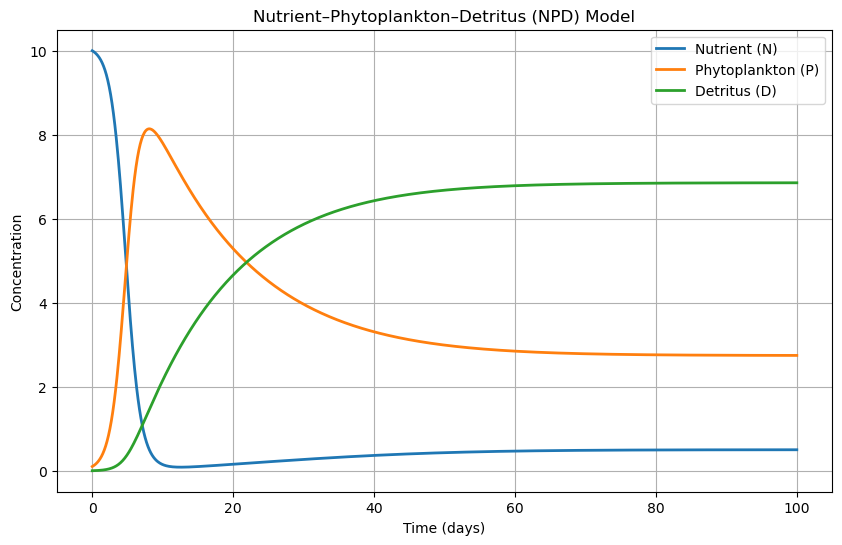

In [11]:

# Parameters
rg = 0.1      # phytoplankton growth rate
m = 0.05      # mortality rate
r = 0.02      # remineralization rate

# Initial conditions
N0 = 10.0
P0 = 0.1
D0 = 0.0

y0 = [N0, P0, D0]

# Time vector
t = np.linspace(0, 100, 1000)

# NPD model
def model(y, t, rg, m, r):

    N, P, D = y

    dNdt = -rg * N * P + r * D

    dPdt = rg * N * P - m * P

    dDdt = m * P - r * D

    return [dNdt, dPdt, dDdt]

# Solve system
sol = odeint(model, y0, t, args=(rg, m, r))

N = sol[:,0]
P = sol[:,1]
D = sol[:,2]

#plot
plt.figure(figsize=(10,6))
plt.plot(t, N, label='Nutrient (N)', linewidth=2)
plt.plot(t, P, label='Phytoplankton (P)', linewidth=2)
plt.plot(t, D, label='Detritus (D)', linewidth=2)
plt.xlabel('Time (days)')
plt.ylabel('Concentration')
plt.title('Nutrient–Phytoplankton–Detritus (NPD) Model')
plt.legend()
plt.grid(True)

plt.show()